In [1]:
# PFE Renault Tanger — Détection d'anomalies
## Notebook 02 : Z-Score + Isolation Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
print("Librairies chargées ✓")

Librairies chargées ✓


In [2]:
df = pd.read_csv("../outputs/dataset_eau_propre.csv", parse_dates=['Date'])

# On travaille uniquement sur les jours de production
df_prod = df[df['TCM'] >= 100].copy().reset_index(drop=True)

print(f"Dataset total    : {len(df)} lignes")
print(f"Jours production : {len(df_prod)} lignes")
print(f"Période          : {df_prod['Date'].min().date()} → {df_prod['Date'].max().date()}")
df_prod[['Date','TCM','KPI_m3_veh','ratio_EOR_ED']].head()

Dataset total    : 112 lignes
Jours production : 86 lignes
Période          : 2026-01-06 → 2026-04-22


,Date,TCM,KPI_m3_veh,ratio_EOR_ED
0,2026-01-06,691.0,1.123010,0.130952
1,2026-01-07,738.0,1.096206,0.052126
2,2026-01-08,910.0,1.000000,0.140187
3,2026-01-09,742.0,1.258760,0.140870
4,2026-01-10,1161.0,1.141258,0.148208


In [3]:
# Z-Score : mesure combien un point est éloigné de la moyenne
# Formule : z = (valeur - moyenne) / écart-type
# Seuil standard : |z| > 2.5 = anomalie

df_prod['zscore_KPI']   = np.abs(stats.zscore(df_prod['KPI_m3_veh'].fillna(df_prod['KPI_m3_veh'].mean())))
df_prod['zscore_conso'] = np.abs(stats.zscore(df_prod['E. Appro Looker']))

SEUIL_ZSCORE = 2.5
df_prod['anomalie_zscore'] = ((df_prod['zscore_KPI']   > SEUIL_ZSCORE) |
                               (df_prod['zscore_conso'] > SEUIL_ZSCORE)).astype(int)

nb_anomalies = df_prod['anomalie_zscore'].sum()
print(f"Anomalies Z-Score détectées : {nb_anomalies} jours sur {len(df_prod)}")
print(f"Taux : {nb_anomalies/len(df_prod)*100:.1f}%")
print()
print(df_prod[df_prod['anomalie_zscore']==1][['Date','TCM','KPI_m3_veh','E. Appro Looker','zscore_KPI']].round(2).to_string(index=False))

Anomalies Z-Score détectées : 4 jours sur 86
Taux : 4.7%

      Date    TCM  KPI_m3_veh  E. Appro Looker  zscore_KPI
2026-02-06 1229.0        0.09            111.0        1.95
2026-03-29  476.0        3.01           1435.0        3.27
2026-04-04  397.0        3.00           1191.0        3.24
2026-04-05  264.0        4.00           1056.0        5.02


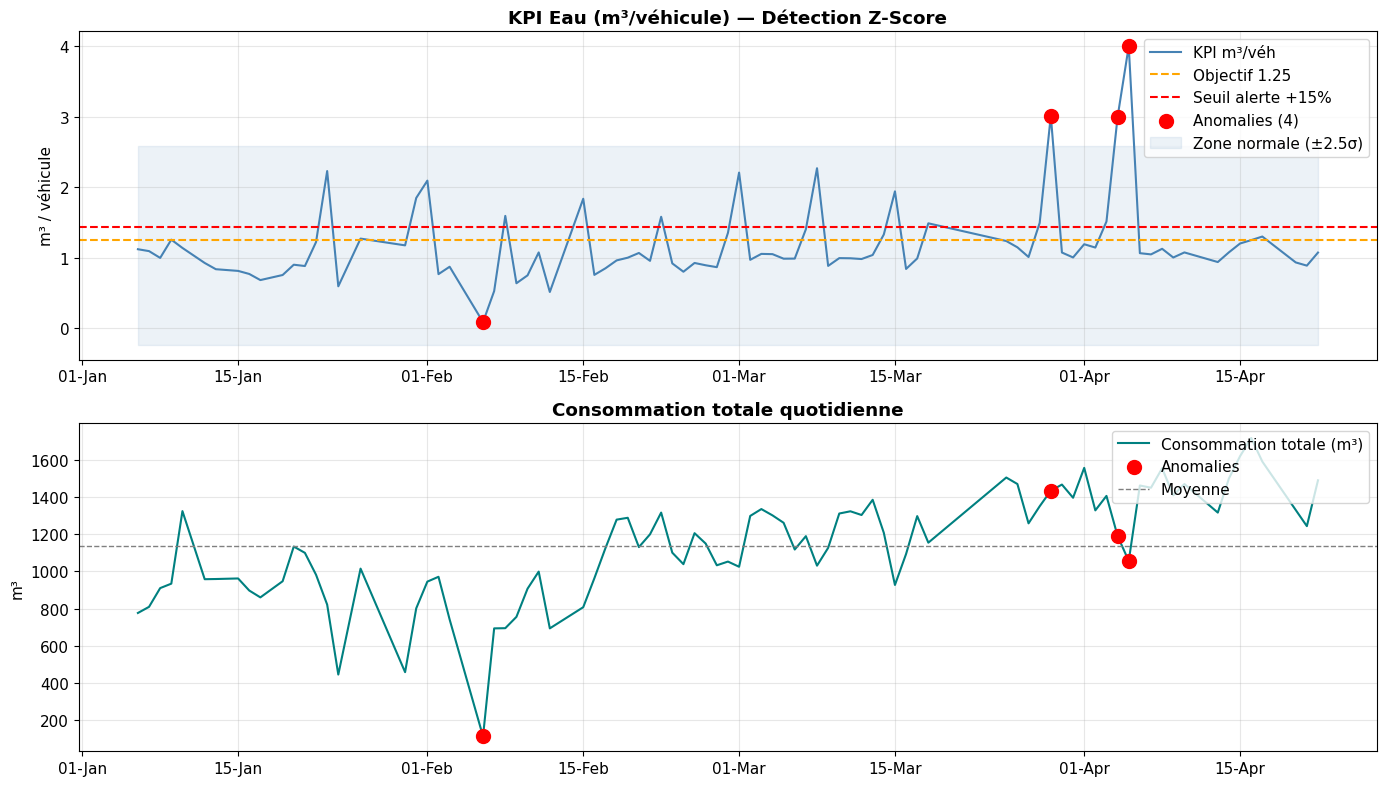

Graphique sauvegardé ✓


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Graphique 1 : KPI avec anomalies
ax1 = axes[0]
normaux  = df_prod[df_prod['anomalie_zscore'] == 0]
anomalies = df_prod[df_prod['anomalie_zscore'] == 1]

ax1.plot(df_prod['Date'], df_prod['KPI_m3_veh'],
         color='steelblue', linewidth=1.5, label='KPI m³/véh')
ax1.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif 1.25')
ax1.axhline(y=1.25*1.15, color='red', linestyle='--', linewidth=1.5, label='Seuil alerte +15%')
ax1.scatter(anomalies['Date'], anomalies['KPI_m3_veh'],
            color='red', s=100, zorder=5, label=f'Anomalies ({len(anomalies)})')
ax1.fill_between(df_prod['Date'],
                 df_prod['KPI_m3_veh'].mean() - 2.5*df_prod['KPI_m3_veh'].std(),
                 df_prod['KPI_m3_veh'].mean() + 2.5*df_prod['KPI_m3_veh'].std(),
                 alpha=0.1, color='steelblue', label='Zone normale (±2.5σ)')
ax1.set_title('KPI Eau (m³/véhicule) — Détection Z-Score', fontweight='bold')
ax1.set_ylabel('m³ / véhicule')
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax1.grid(True, alpha=0.3)

# Graphique 2 : Consommation totale
ax2 = axes[1]
ax2.plot(df_prod['Date'], df_prod['E. Appro Looker'],
         color='teal', linewidth=1.5, label='Consommation totale (m³)')
ax2.scatter(anomalies['Date'], anomalies['E. Appro Looker'],
            color='red', s=100, zorder=5, label='Anomalies')
ax2.axhline(y=df_prod['E. Appro Looker'].mean(), color='gray',
            linestyle='--', linewidth=1, label='Moyenne')
ax2.set_title('Consommation totale quotidienne', fontweight='bold')
ax2.set_ylabel('m³')
ax2.legend(loc='upper right')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/anomalies_zscore.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [5]:
# Isolation Forest : algorithme ML non-supervisé
# Principe : les anomalies sont plus faciles à "isoler" que les points normaux
# contamination = pourcentage estimé d'anomalies dans les données

FEATURES = ['KPI_m3_veh', 'E. Appro Looker', 'ED_Total',
            'EOR_Total', 'TCM', 'ratio_EOR_ED']

# Préparer les données (supprimer les NaN pour le ML)
df_ml = df_prod[FEATURES].copy()
df_ml = df_ml.fillna(df_ml.mean())

# Normalisation (important pour Isolation Forest)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)

# Entraînement
iso_forest = IsolationForest(
    contamination=0.08,   # on estime ~8% de jours anormaux
    random_state=42,
    n_estimators=100
)
df_prod['anomalie_IF'] = iso_forest.fit_predict(X_scaled)
df_prod['anomalie_IF'] = (df_prod['anomalie_IF'] == -1).astype(int)  # -1=anomalie → 1
df_prod['score_IF']    = iso_forest.score_samples(X_scaled)          # score de normalité

nb_if = df_prod['anomalie_IF'].sum()
print(f"Anomalies Isolation Forest : {nb_if} jours sur {len(df_prod)}")
print(f"Taux : {nb_if/len(df_prod)*100:.1f}%")
print()
print(df_prod[df_prod['anomalie_IF']==1][['Date','TCM','KPI_m3_veh','E. Appro Looker','score_IF']].round(3).to_string(index=False))

Anomalies Isolation Forest : 7 jours sur 86
Taux : 8.1%

      Date    TCM  KPI_m3_veh  E. Appro Looker  score_IF
2026-01-24  743.0       0.598            444.0    -0.627
2026-01-30  388.0       1.178            457.0    -0.666
2026-02-01  451.0       2.095            945.0    -0.554
2026-02-06 1229.0       0.090            111.0    -0.590
2026-02-26 1284.0       0.896           1150.0    -0.559
2026-03-29  476.0       3.015           1435.0    -0.559
2026-04-05  264.0       4.000           1056.0    -0.639


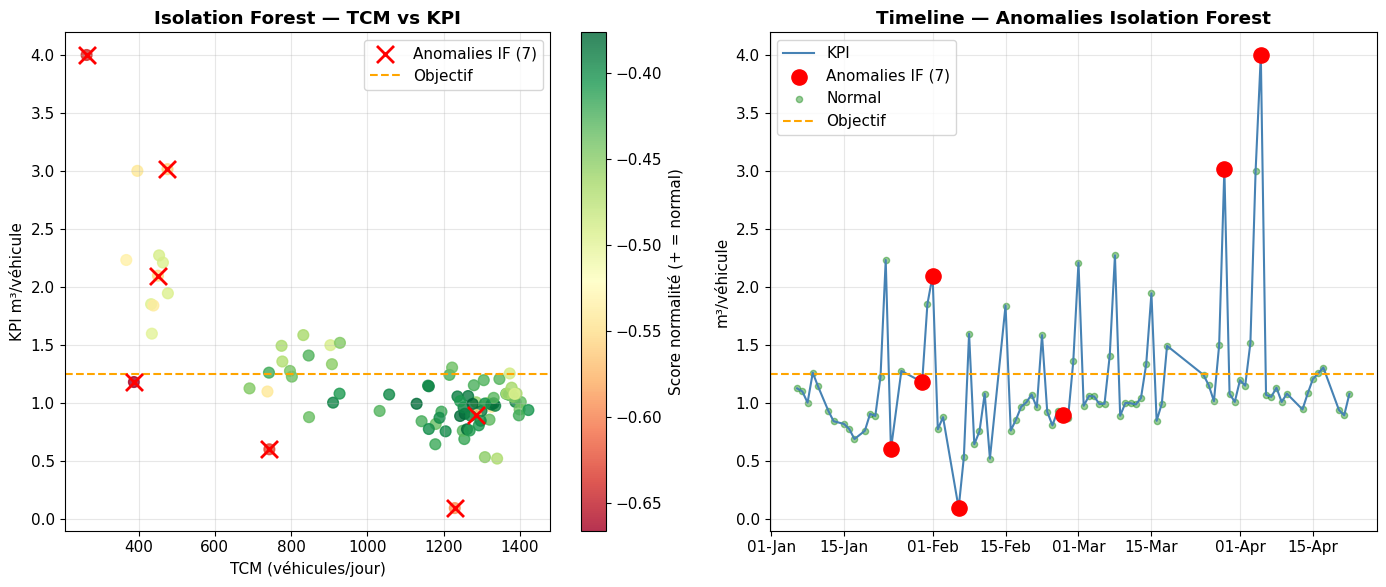

Graphique sauvegardé ✓


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : KPI coloré par score IF
ax1 = axes[0]
scatter = ax1.scatter(df_prod['TCM'], df_prod['KPI_m3_veh'],
                      c=df_prod['score_IF'], cmap='RdYlGn',
                      s=60, alpha=0.8)
plt.colorbar(scatter, ax=ax1, label='Score normalité (+ = normal)')
anomalies_if = df_prod[df_prod['anomalie_IF'] == 1]
ax1.scatter(anomalies_if['TCM'], anomalies_if['KPI_m3_veh'],
            color='red', s=150, marker='x', linewidths=2,
            label=f'Anomalies IF ({len(anomalies_if)})', zorder=5)
ax1.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif')
ax1.set_xlabel('TCM (véhicules/jour)')
ax1.set_ylabel('KPI m³/véhicule')
ax1.set_title('Isolation Forest — TCM vs KPI', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2 : Timeline avec anomalies IF
ax2 = axes[1]
ax2.plot(df_prod['Date'], df_prod['KPI_m3_veh'],
         color='steelblue', linewidth=1.5, label='KPI')
ax2.scatter(anomalies_if['Date'], anomalies_if['KPI_m3_veh'],
            color='red', s=120, zorder=5, label=f'Anomalies IF ({len(anomalies_if)})')
normaux_if = df_prod[df_prod['anomalie_IF'] == 0]
ax2.scatter(normaux_if['Date'], normaux_if['KPI_m3_veh'],
            color='green', s=20, alpha=0.4, label='Normal')
ax2.axhline(y=1.25, color='orange', linestyle='--', linewidth=1.5, label='Objectif')
ax2.set_title('Timeline — Anomalies Isolation Forest', fontweight='bold')
ax2.set_ylabel('m³/véhicule')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/anomalies_isolation_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé ✓")

In [7]:
# Une anomalie confirmée = détectée par AU MOINS une méthode
# Une anomalie forte    = détectée par LES DEUX méthodes

df_prod['anomalie_finale'] = ((df_prod['anomalie_zscore'] == 1) |
                               (df_prod['anomalie_IF']     == 1)).astype(int)
df_prod['anomalie_forte']  = ((df_prod['anomalie_zscore'] == 1) &
                               (df_prod['anomalie_IF']     == 1)).astype(int)

print("=== RÉSUMÉ FINAL ===")
print(f"Z-Score seul          : {df_prod['anomalie_zscore'].sum()} anomalies")
print(f"Isolation Forest seul : {df_prod['anomalie_IF'].sum()} anomalies")
print(f"Détectées par les 2   : {df_prod['anomalie_forte'].sum()} anomalies (CONFIRMÉES)")
print(f"Total (au moins 1)    : {df_prod['anomalie_finale'].sum()} anomalies")
print()
print("=== ANOMALIES CONFIRMÉES (les 2 méthodes) ===")
confirmes = df_prod[df_prod['anomalie_forte']==1]
print(confirmes[['Date','TCM','KPI_m3_veh','E. Appro Looker','zscore_KPI']].round(2).to_string(index=False))

=== RÉSUMÉ FINAL ===
Z-Score seul          : 4 anomalies
Isolation Forest seul : 7 anomalies
Détectées par les 2   : 3 anomalies (CONFIRMÉES)
Total (au moins 1)    : 8 anomalies

=== ANOMALIES CONFIRMÉES (les 2 méthodes) ===
      Date    TCM  KPI_m3_veh  E. Appro Looker  zscore_KPI
2026-02-06 1229.0        0.09            111.0        1.95
2026-03-29  476.0        3.01           1435.0        3.27
2026-04-05  264.0        4.00           1056.0        5.02


In [8]:
# Sauvegarder le dataset avec les colonnes anomalies
df_prod.to_csv("../outputs/dataset_avec_anomalies.csv", index=False)

print(f"Dataset enrichi sauvegardé ✓")
print(f"Nouvelles colonnes : anomalie_zscore, anomalie_IF, anomalie_finale, anomalie_forte, score_IF")
print(f"Lignes : {len(df_prod)} | Colonnes : {len(df_prod.columns)}")

Dataset enrichi sauvegardé ✓
Nouvelles colonnes : anomalie_zscore, anomalie_IF, anomalie_finale, anomalie_forte, score_IF
Lignes : 86 | Colonnes : 71


In [9]:
# Cellule à ajouter dans ton notebook 02

def expliquer_anomalie(row):
    causes = []
    
    if row['TCM'] < 500:
        causes.append(f"Production très faible ({int(row['TCM'])} véh) → ratio gonflé")
    if row['ratio_EOR_ED'] < 0.10:
        causes.append(f"Recyclage EOR faible ({row['ratio_EOR_ED']:.1%}) → sur-consommation ED")
    if row['EI_Looker'] > 1200:
        causes.append(f"Eau industrielle élevée ({row['EI_Looker']:.0f} m³)")
    if row['EP_Looker'] > 500:
        causes.append(f"Eau potable élevée ({row['EP_Looker']:.0f} m³)")
    if row['is_lundi'] == 1:
        causes.append("Lundi — redémarrage après weekend (consommation typiquement haute)")
    if not causes:
        causes.append("Cause non identifiée — à vérifier terrain")
    
    return " | ".join(causes)

anomalies = df_prod[df_prod['anomalie_finale'] == 1].copy()
anomalies['cause_probable'] = anomalies.apply(expliquer_anomalie, axis=1)
print(anomalies[['Date','KPI_m3_veh','cause_probable']].to_string(index=False))



      Date  KPI_m3_veh                                                                                      cause_probable
2026-01-24    0.597577                                                           Cause non identifiée — à vérifier terrain
2026-01-30    1.177835                                                     Production très faible (388 véh) → ratio gonflé
2026-02-01    2.095344 Production très faible (451 véh) → ratio gonflé | Recyclage EOR faible (7.4%) → sur-consommation ED
2026-02-06    0.090317                                                           Cause non identifiée — à vérifier terrain
2026-02-26    0.895639                                                           Cause non identifiée — à vérifier terrain
2026-03-29    3.014706                 Production très faible (476 véh) → ratio gonflé | Eau industrielle élevée (1325 m³)
2026-04-04    3.000000                                                     Production très faible (397 véh) → ratio gonflé
2026-04-05    4.